In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/Banking.csv')

In [4]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [6]:
df['Banking Contact'].nunique()

49

In [ ]:
df['Estimated Income']

,Estimated Income
0,75384.77
1,289834.31
2,169935.23
3,356808.11
4,130711.68
...,...
2995,297617.14
2996,42397.46
2997,48339.88
2998,107265.87


In [7]:
bins = [0, 100000 , 300000 , float('inf')]
labels = ['Low' , 'Medium' , 'High']
df['Estimated Income Band'] = pd.cut(df['Estimated Income'] , bins = bins , labels = labels , include_lowest = True)

In [8]:
df['Estimated Income Band']

,Estimated Income Band
0,Low
1,Medium
2,Medium
3,High
4,Medium
...,...
2995,Medium
2996,Low
2997,Low
2998,Medium


In [9]:
df.isnull().sum()

,0
Client ID,0
Name,0
Age,0
Location ID,0
Joined Bank,0
Banking Contact,0
Nationality,0
Occupation,0
Fee Structure,0
Loyalty Classification,0


In [10]:
df['Joined Bank'] = pd.to_datetime(df['Joined Bank'] , format = '%d-%m-%Y')


In [11]:
df['Joined Bank']

,Joined Bank
0,2019-05-06
1,2001-12-10
2,2010-01-25
3,2019-03-28
4,2012-07-20
...,...
2995,2014-10-09
2996,2009-02-05
2997,2009-12-29
2998,2006-02-13


In [12]:
categorical_cols = df[["Risk Weighting","Nationality","Occupation","Fee Structure","Loyalty Classification","Properties Owned","Risk Weighting","Occupation","Estimated Income Band"]].columns
for col in categorical_cols:
  # if col in ["Client ID","Name","Joined Bank"]:
  #   continue
  print(f"\nValue Counts for '{col}':")
  display(df[col].value_counts())


Value Counts for 'Risk Weighting':


,count
Risk Weighting,
2,1222
1,836
3,460
4,322
5,160



Value Counts for 'Nationality':


,count
Nationality,
European,1309
Asian,754
American,507
Australian,254
African,176



Value Counts for 'Occupation':


...

,count
Risk Weighting,
2,1222
1,836
3,460
4,322
5,160



Value Counts for 'Occupation':


,count
Occupation,
Associate Professor,28
Structural Analysis Engineer,28
Recruiter,25
Account Coordinator,24
Human Resources Manager,24
...,...
Office Assistant IV,8
Automation Specialist I,7
Computer Systems Analyst I,6



Value Counts for 'Estimated Income Band':


,count
Estimated Income Band,
Medium,1517
Low,1027
High,456


In [13]:
df.describe()

,Age,Location ID,Joined Bank,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,2010-08-15 00:03:21.600000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
min,17.000000,12.000000,1995-01-03 00:00:00,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,2004-04-01 18:00:00,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,2011-02-18 00:00:00,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,2017-12-24 06:00:00,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,2021-12-31 00:00:00,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000
std,19.854760,12462.273017,NaN,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242


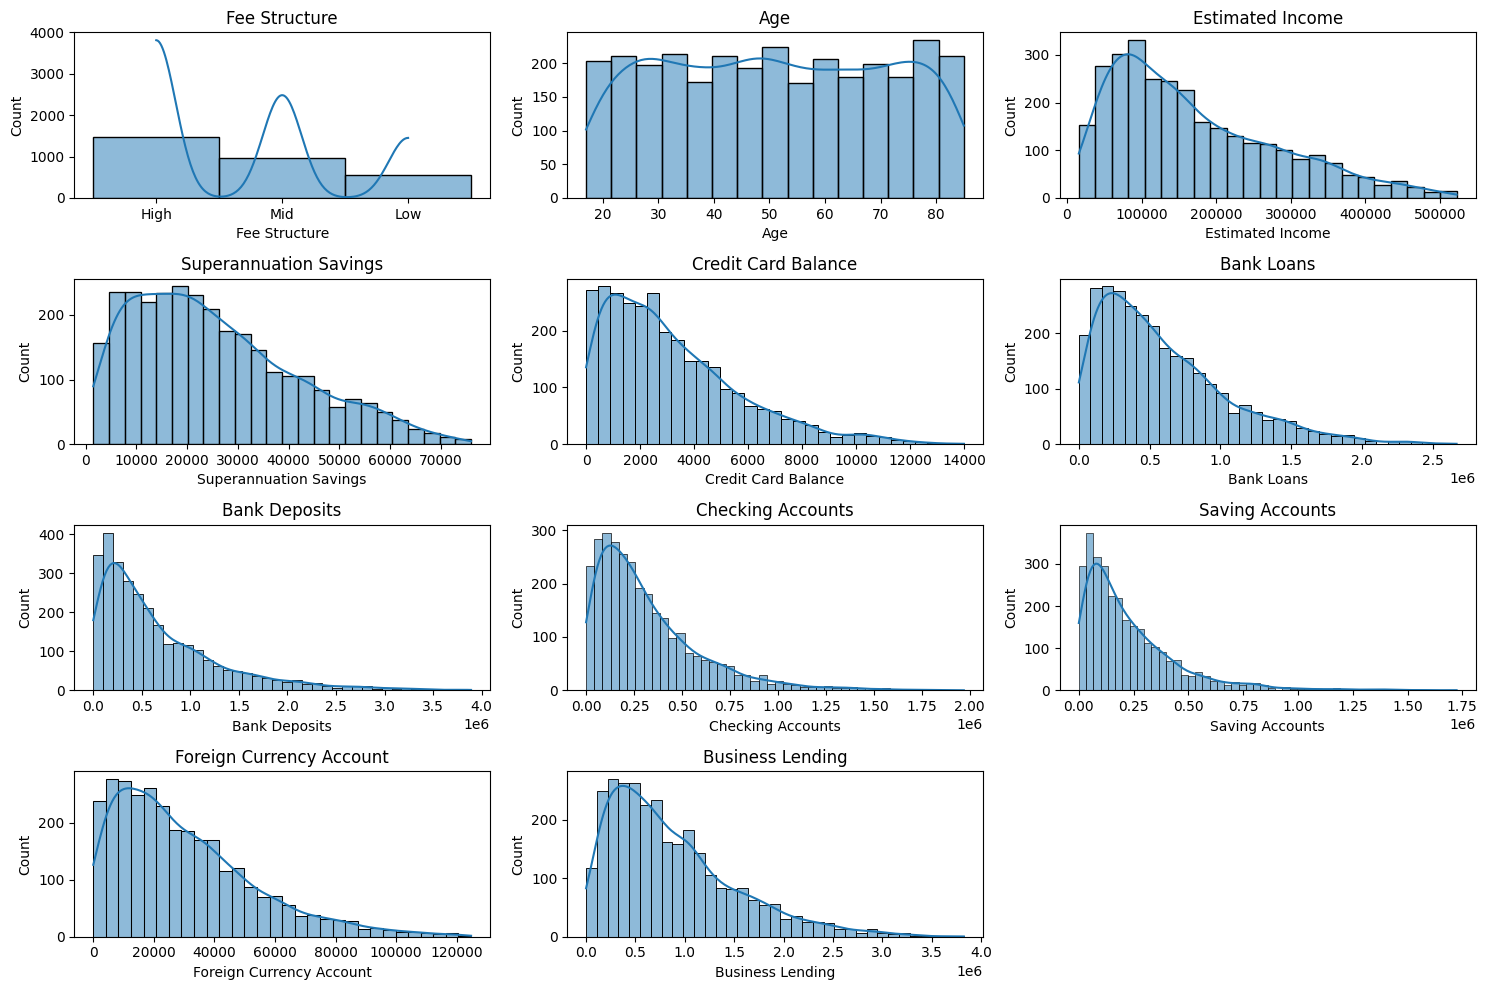

In [14]:
numerical_cols = ['Fee Structure','Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
numerical_cols = ['Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance',
                  'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
                  'Foreign Currency Account', 'Business Lending', 'Properties Owned']


correlation_matrix = df[numerical_cols].corr()

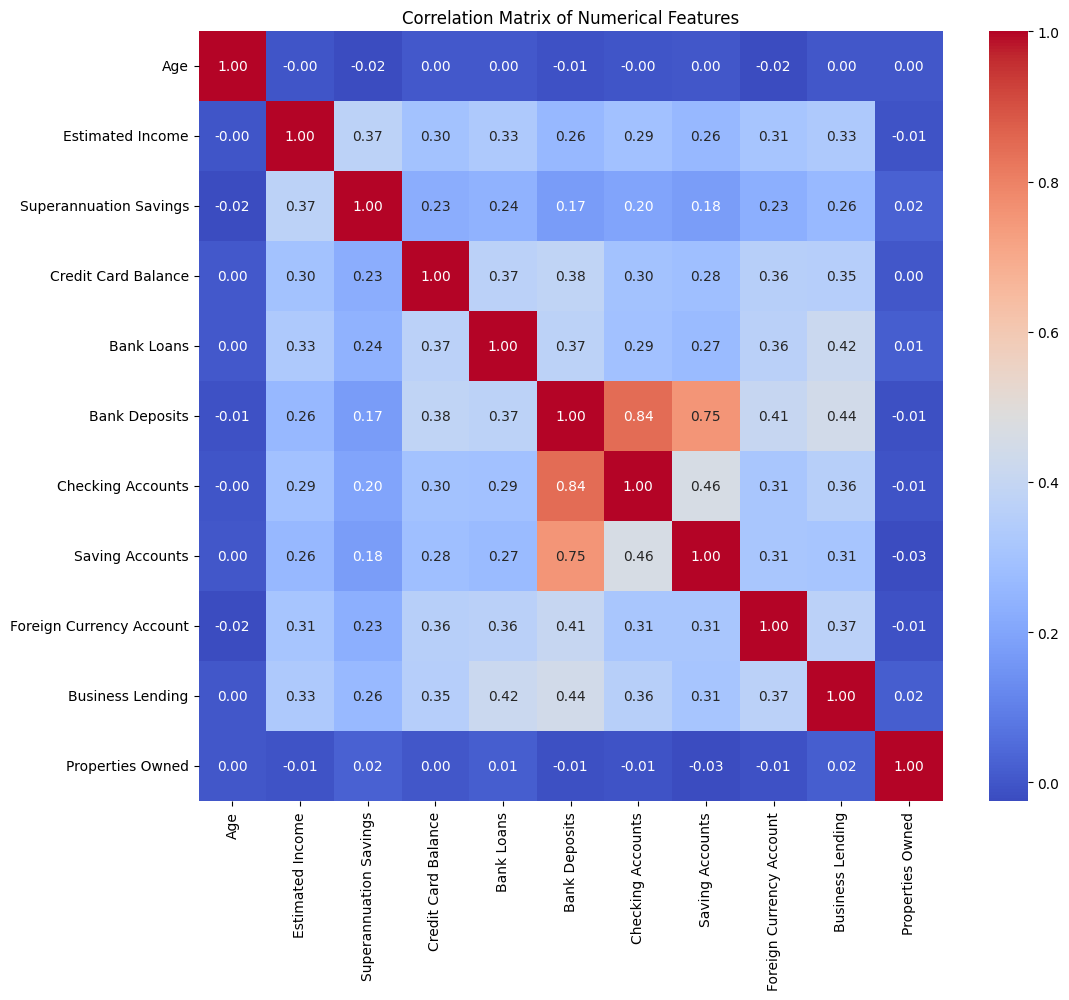

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

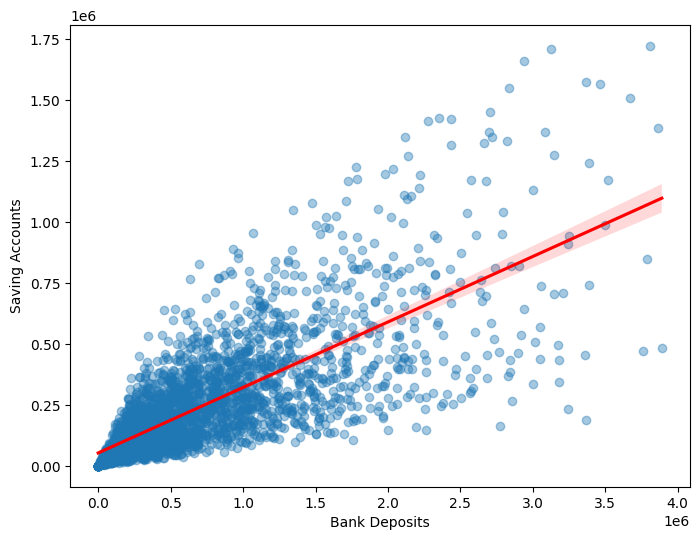

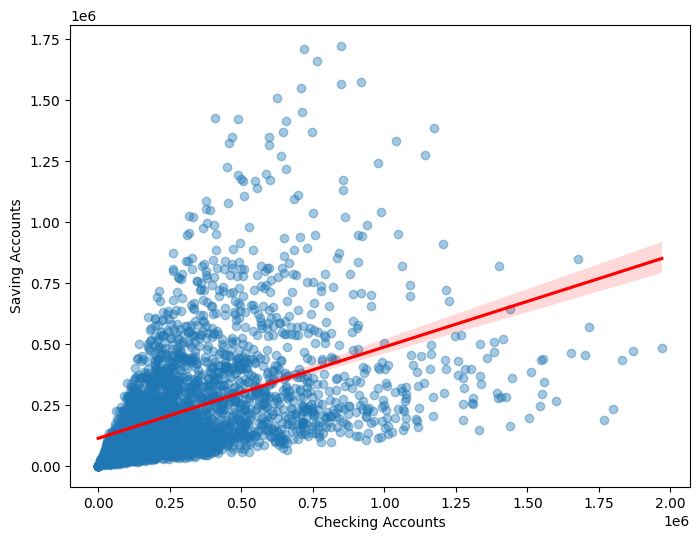

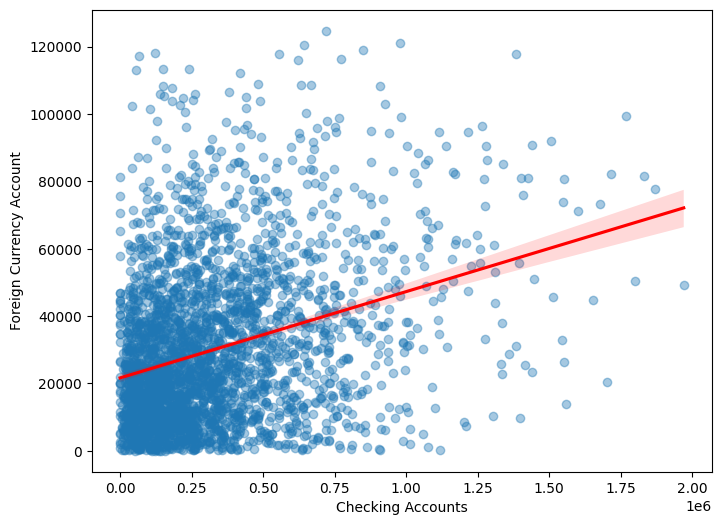

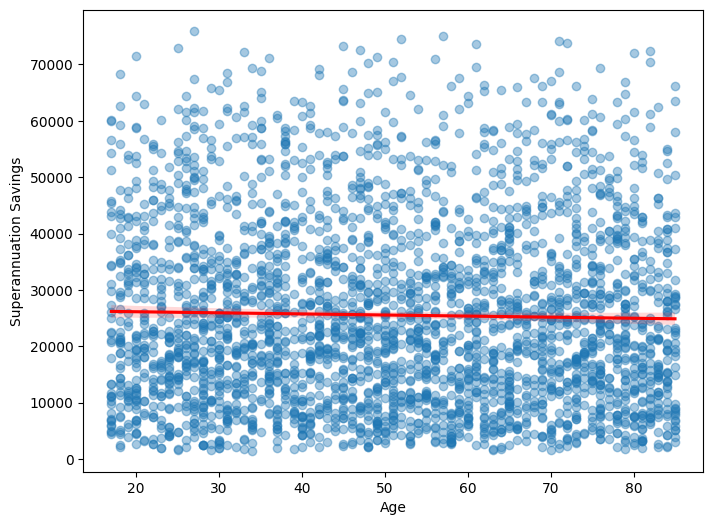

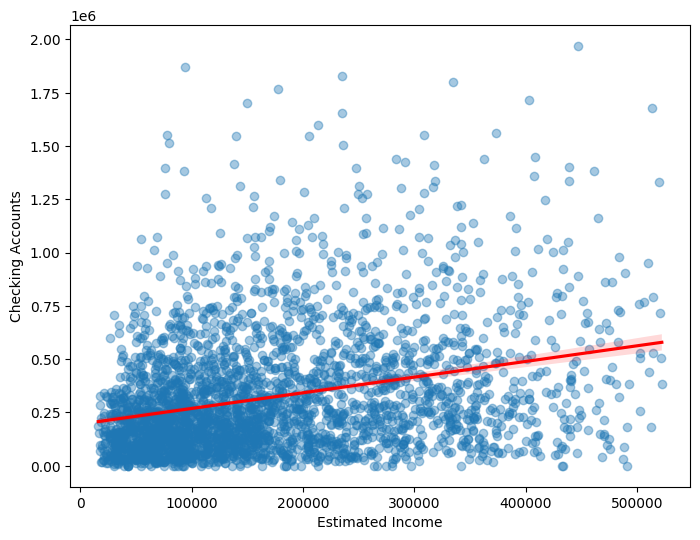

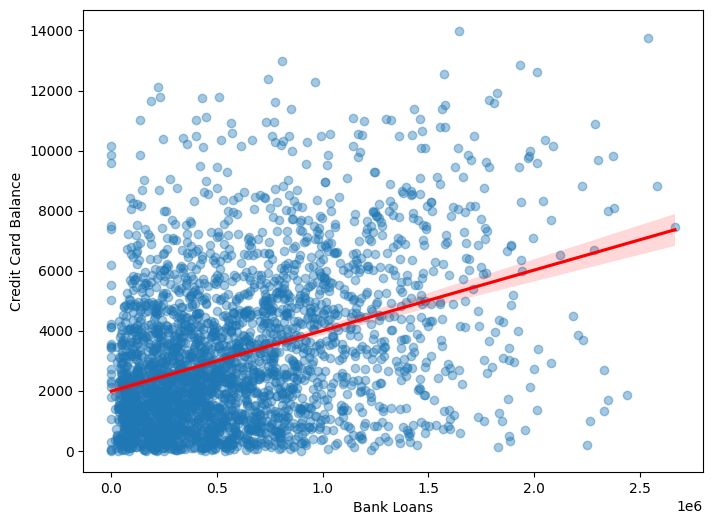

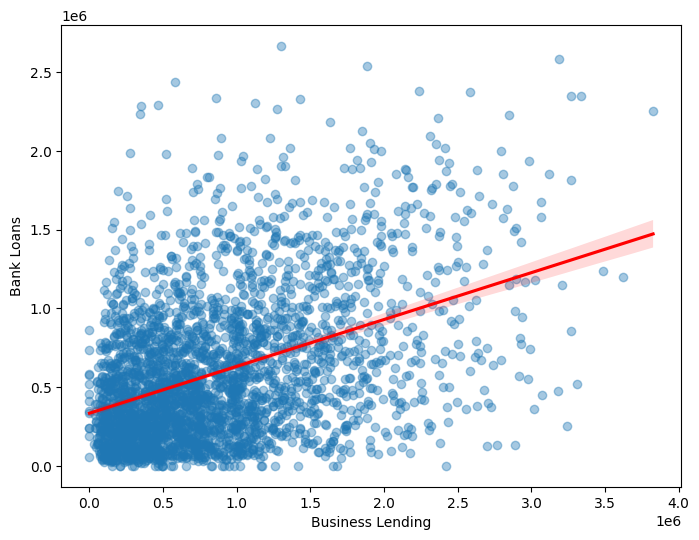

In [17]:
pairs_to_plot = [
    ('Bank Deposits', 'Saving Accounts'),
    ('Checking Accounts', 'Saving Accounts'),
    ('Checking Accounts', 'Foreign Currency Account'),
    ('Age', 'Superannuation Savings'),
    ('Estimated Income', 'Checking Accounts'),
    ('Bank Loans', 'Credit Card Balance'),
    ('Business Lending', 'Bank Loans'),
]

for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.4},     # semi-transparent points
        line_kws={'color': 'red'}       # best-fit line color
    )

# 📊 Key Insights & Business Interpretation

---

## 1. Deposits and Savings Behavior 💰

### Observation

A strong positive relationship was observed between **Bank Deposits** and **Saving Account balances**.

### Interpretation

This pattern suggests that customers who maintain higher deposit balances also tend to accumulate larger savings. These variables may reflect closely related financial habits such as:

* Consistent fund allocation into banking products
* Long-term saving behavior
* Higher overall financial engagement with the bank

### Business Insight

Customers with strong deposit activity could represent high-value customer segments and may be suitable targets for premium savings or investment products.

---

## 2. Income, Age & Wealth Accumulation 📈

### Observation

**Age** and **Estimated Income** showed moderate positive correlations with:

* Savings Accounts
* Checking Accounts
* Superannuation Savings
* Certain credit and loan balances

### Interpretation

The results align with typical financial lifecycle behavior:

* Older individuals generally accumulate more financial assets over time.
* Higher-income customers tend to maintain larger balances and retirement savings.
* Increased earning potential often translates into broader use of banking services.

### Business Insight

Segmenting customers by age and income may improve personalized financial product recommendations and long-term retention strategies.

---

## 3. Property Ownership Shows Limited Association 🏠

### Observation

The number of **Properties Owned** displayed relatively weak relationships with most banking variables.

### Interpretation

Property ownership appears to be influenced by additional external factors beyond banking behavior, such as:

* Geographic location
* Real estate market conditions
* Family wealth or inheritance
* Personal investment decisions

### Business Insight

Property ownership alone may not be a strong predictor of customer banking activity and should be combined with other financial indicators.

---

## 4. Business Lending vs Personal Banking 🏢

### Observation

**Business Lending** demonstrated a moderate relationship with **Bank Loans**, while remaining relatively independent from deposits and property-related variables.

### Interpretation

This may indicate a customer segment that simultaneously manages:

* Personal borrowing
* Business financing requirements

At the same time, business lending appears to serve a more specialized group with distinct financial patterns.

### Business Insight

Separate analytical strategies for personal and business banking customers may provide more accurate customer profiling and decision-making.

---

## 📌 Overall Conclusion

The analysis reveals that customer financial behavior is strongly influenced by account activity, income levels, and lifecycle factors. Deposit and savings products exhibit interconnected usage patterns, while business and property-related variables represent more specialized customer characteristics.

